# Identifying Plant Types using K-Means

**Unsupervised Machine Learning for Plant Classification**

Compare clustering quality using:
- Raw pixel features
- Handcrafted features (color histogram + HOG)
- Pretrained CNN embeddings

Evaluate with **silhouette score** and visual cluster analysis.

## Phase 1: Setup and load data

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if "notebooks" in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import config
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from src.data_loader import load_all_image_paths, load_inaturalist2021_plants

if config.DATASET_SOURCE == "inaturalist2021":
    print("Loading iNaturalist 2021 (plants only)...")
    paths, labels, label_to_idx = load_inaturalist2021_plants(
        root=config.INATURALIST_DIR,
        version=config.INATURALIST_VERSION,
        max_images=config.INATURALIST_MAX_IMAGES,
        download=True,
        random_state=config.RANDOM_SEED,
    )
else:
    paths, labels, label_to_idx = load_all_image_paths(
        config.RAW_DATA_DIR,
        max_images=config.MAX_IMAGES
    )

if len(paths) == 0:
    raise FileNotFoundError(
        f"No images found. For local: add images to data/raw/trees/, bushes/, flowers/. "
        f"For iNaturalist: set config.DATASET_SOURCE = 'inaturalist2021' and run again."
    )

print(f"Total images: {len(paths)}")
if label_to_idx and labels is not None:
    n_unique = len(np.unique(labels))
    print(f"Unique species/classes: {n_unique}")

Loading iNaturalist 2021 (plants only)...
Total images: 10000
Unique species/classes: 3871


## Phase 2: Feature extraction

Extract three feature types: raw pixels, handcrafted, CNN embeddings.

In [3]:
from src.features import (
    extract_raw_pixels_from_paths,
    extract_handcrafted_from_paths,
    extract_cnn_embeddings,
)

# Raw pixels (small size to keep dim manageable)
X_raw = extract_raw_pixels_from_paths(paths, size=config.IMG_SIZE)
print(f"Raw pixels shape: {X_raw.shape}")

# Handcrafted (color histogram + HOG)
X_handcrafted = extract_handcrafted_from_paths(paths, size=config.IMG_SIZE)
print(f"Handcrafted shape: {X_handcrafted.shape}")

# CNN embeddings
X_cnn = extract_cnn_embeddings(paths, backbone=config.CNN_BACKBONE, size=config.IMG_SIZE_CNN)
print(f"CNN embeddings shape: {X_cnn.shape}")

Raw pixels shape: (10000, 12288)


Handcrafted shape: (10000, 1860)
CNN embeddings shape: (10000, 512)


## Phase 3: K-Means clustering and silhouette evaluation

In [4]:
from src.clustering import (
    run_kmeans,
    tune_k,
    evaluate_silhouette,
    apply_pca,
)
from sklearn.preprocessing import StandardScaler

def cluster_and_evaluate(X, name, use_pca=False):
    """Run K-Means tuning and return best model, labels, scores."""
    if use_pca and X.shape[1] > 100:
        X_use, pca, scaler = apply_pca(X, variance_retained=config.PCA_VARIANCE_RETAINED)
        print(f"  PCA: {X.shape[1]} -> {X_use.shape[1]} dims")
    else:
        scaler = StandardScaler()
        X_use = scaler.fit_transform(X)

    result = tune_k(
        X_use,
        config.K_RANGE,
        init=config.K_MEANS_INIT,
        n_init=config.K_MEANS_N_INIT,
        max_iter=config.K_MEANS_MAX_ITER,
        random_state=config.RANDOM_SEED,
    )
    kmeans, labels, _ = run_kmeans(
        X_use, result["best_k"],
        init=config.K_MEANS_INIT,
        n_init=config.K_MEANS_N_INIT,
        max_iter=config.K_MEANS_MAX_ITER,
        random_state=config.RANDOM_SEED,
    )
    sil, _ = evaluate_silhouette(X_use, labels)
    print(f"{name}: best k={result['best_k']}, silhouette={sil:.4f}")
    return kmeans, labels, result, X_use

# Compare all feature types
results = {}
results["raw"] = cluster_and_evaluate(X_raw, "Raw pixels", use_pca=config.USE_PCA_FOR_RAW)
results["handcrafted"] = cluster_and_evaluate(X_handcrafted, "Handcrafted")
results["cnn"] = cluster_and_evaluate(X_cnn, "CNN embeddings")

  PCA: 12288 -> 1671 dims
Raw pixels: best k=4, silhouette=0.0631
Handcrafted: best k=5, silhouette=-0.0018
CNN embeddings: best k=4, silhouette=0.0378


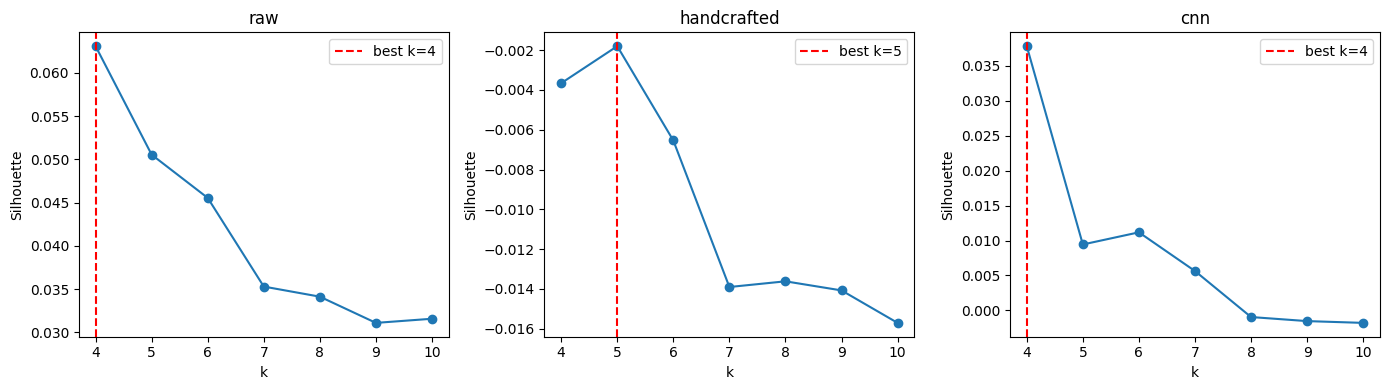

In [5]:
# Plot silhouette vs k for each feature type
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (_, _, res, _)) in zip(axes, results.items()):
    ax.plot(res["k_values"], res["silhouette_scores"], "o-")
    ax.axvline(res["best_k"], color="red", ls="--", label=f"best k={res['best_k']}")
    ax.set_xlabel("k"); ax.set_ylabel("Silhouette"); ax.set_title(name); ax.legend()
plt.tight_layout()
plt.savefig(config.RESULTS_DIR / "silhouette_vs_k.png", dpi=150)
plt.show()

## Phase 4: Visualize cluster samples

In [6]:
from PIL import Image


def plot_cluster_gallery(paths, cluster_labels, n_samples=5, title="Clusters"):
    """Show up to n_samples images from each cluster."""
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)
    fig, axes = plt.subplots(
        n_clusters,
        n_samples,
        figsize=(n_samples * 2, max(n_clusters * 2, 2)),
        squeeze=False,
    )

    for row, cluster_id in enumerate(unique_clusters):
        cluster_idx = np.where(cluster_labels == cluster_id)[0]
        sample_idx = cluster_idx[:n_samples]

        for col, path_idx in enumerate(sample_idx):
            img = Image.open(paths[path_idx]).convert("RGB")
            img = img.resize((80, 80))
            axes[row, col].imshow(img)
            axes[row, col].axis("off")

        for col in range(len(sample_idx), n_samples):
            axes[row, col].axis("off")

        axes[row, 0].set_ylabel(
            f"Cluster {cluster_id} (n={len(cluster_idx)})",
            fontsize=10,
            rotation=0,
            labelpad=42,
            va="center",
        )

    fig.suptitle(title)
    plt.tight_layout()
    return fig


### CNN embedding clusters

Five images from each cluster produced from the CNN embedding representation.


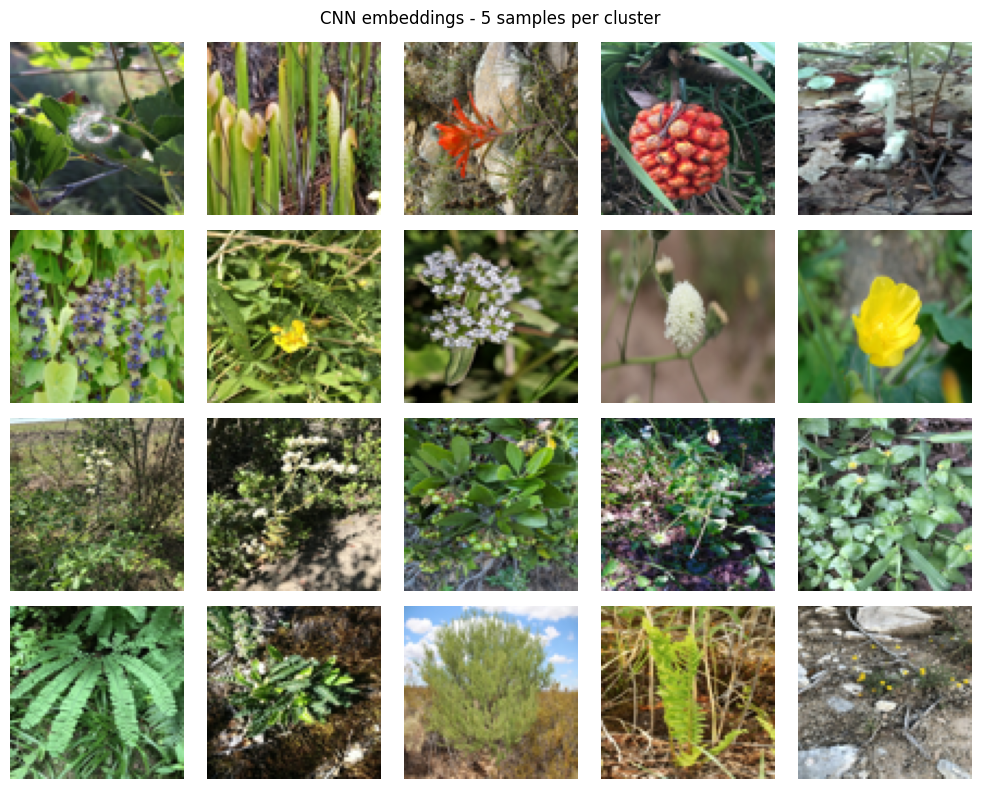

In [7]:
_, labels_cnn, _, _ = results["cnn"]
fig = plot_cluster_gallery(
    paths,
    labels_cnn,
    n_samples=5,
    title="CNN embeddings - 5 samples per cluster",
)
fig.savefig(config.RESULTS_DIR / "cluster_gallery_cnn.png", dpi=150, bbox_inches="tight")
plt.show()


### Raw pixel clusters

Five images from each cluster produced from the raw pixel representation.


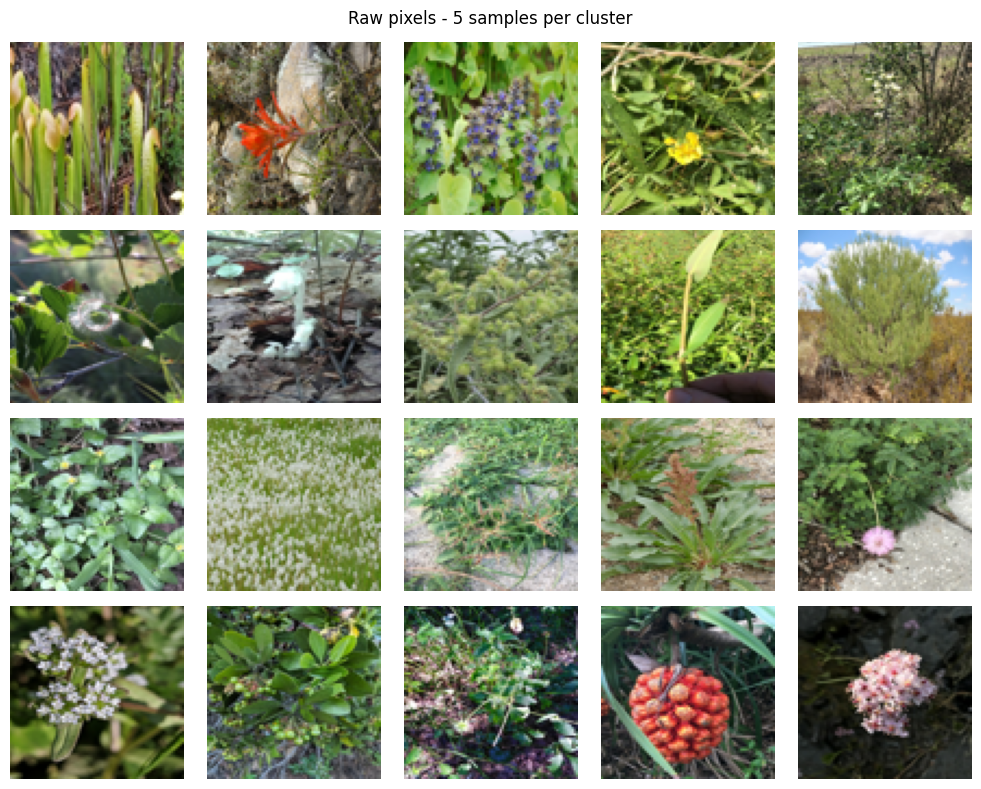

In [8]:
_, labels_raw, _, _ = results["raw"]
fig = plot_cluster_gallery(
    paths,
    labels_raw,
    n_samples=5,
    title="Raw pixels - 5 samples per cluster",
)
fig.savefig(config.RESULTS_DIR / "cluster_gallery_raw.png", dpi=150, bbox_inches="tight")
plt.show()


### Handcrafted feature clusters

Five images from each cluster produced from the handcrafted color histogram + HOG representation.


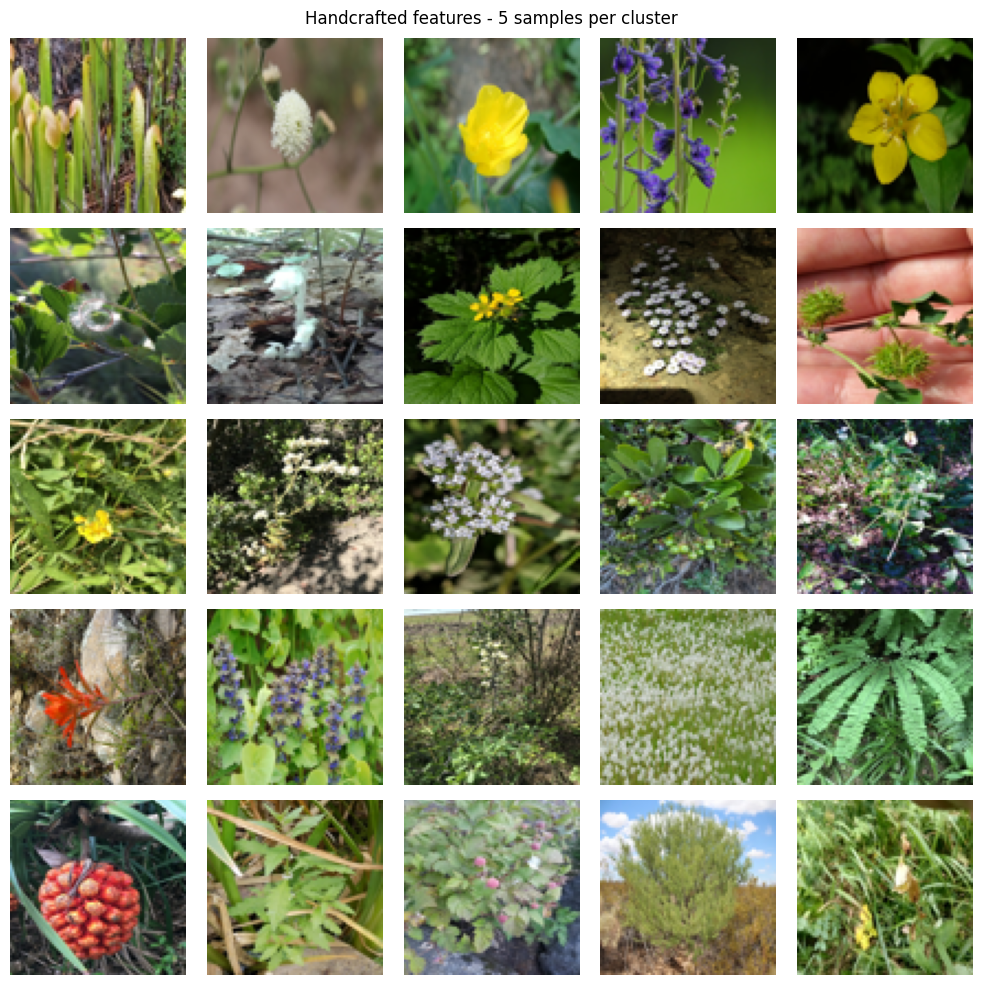

In [9]:
_, labels_handcrafted, _, _ = results["handcrafted"]
fig = plot_cluster_gallery(
    paths,
    labels_handcrafted,
    n_samples=5,
    title="Handcrafted features - 5 samples per cluster",
)
fig.savefig(config.RESULTS_DIR / "cluster_gallery_handcrafted.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary: Compare feature methods

In [10]:
print("\n--- Clustering comparison ---")
for name, (_, labels, res, _) in results.items():
    sil, _ = evaluate_silhouette(
        results[name][3], labels
    )
    print(f"{name:12s}: k={res['best_k']}, silhouette={sil:.4f}")
print("\nExpected: CNN embeddings typically yield best silhouette and most interpretable clusters.")


--- Clustering comparison ---
raw         : k=4, silhouette=0.0631
handcrafted : k=5, silhouette=-0.0018
cnn         : k=4, silhouette=0.0378

Expected: CNN embeddings typically yield best silhouette and most interpretable clusters.
